In [34]:
import pandas as pd


def data_extract(df, target_value):
    """
    Extracts the text and title from the dataframe and  adds a label column.
    """

    # add a target column to the dataframe
    df["label"] = target_value

    # return a df copy with text, title and label columns
    return df[["text", "title", "label"]]


DATA_CONFIG = [
    {
        "filename": "BuzzFeed_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "BuzzFeed_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {
        "filename": "PolitiFact_fake_news_content.csv",
        "extract_func": data_extract,
        "target_value": "FAKE",
    },
    {
        "filename": "PolitiFact_real_news_content.csv",
        "extract_func": data_extract,
        "target_value": "TRUE",
    },
    {"filename": "Fake.csv", "extract_func": data_extract, "target_value": "FAKE"},
    {"filename": "True.csv", "extract_func": data_extract, "target_value": "TRUE"},
]


def load_merge_data(data_config):
    """
    Loads and merges the data from the given config.
    """
    dataframes = []

    for config in data_config:
        filepath = f"./data/{config['filename']}"
        df = pd.read_csv(filepath)
        df = config["extract_func"](df, config["target_value"])
        dataframes.append(df)

    # concatenate all dataframes into one
    merged_df = pd.concat(dataframes, ignore_index=True)

    return merged_df


def basic_sanity_check(df):
    """
    Performs a basic sanity check on the dataframe.
    """

    # sanity check title
    print("=" * 20)
    print("{:^20}".format("Sanity Check"))
    print("=" * 20)

    # check for missing values
    if df.isnull().values.any():
        print("Missing values found in the dataframe.")
        # remove rows with missing values
        df = df.dropna()

    # check for duplicates
    if df.duplicated().any():
        # check for duplicate rows
        duplicate_rows = df.duplicated().sum()
        print(f"Duplicate rows found: {duplicate_rows}")
        # remove duplicate rows
        df = df.drop_duplicates().reset_index(drop=True)
        print("Duplicate rows removed.")

    # check for empty strings
    if (df["text"] == "").any() or (df["title"] == "").any():
        print("Empty strings found in the dataframe.")
        # remove rows with empty strings
        df = df[(df["text"] != "") & (df["title"] != "")].reset_index(drop=True)
        print("Empty strings removed.")

    # check the shape of the dataframe
    print(f"Dataframe has {df.shape[0]} rows and {df.shape[1]} columns.")
    print(f"Dataframe has {df['label'].nunique()} unique labels.")

    print("=" * 20)


def save_data(df, path):
    """
    Saves the dataframe to a csv file.
    """
    df.to_csv(path, index=False)
    print(f"Data saved to {path}")


def generate_raw_data():
    raw_data = load_merge_data(DATA_CONFIG)
    basic_sanity_check(raw_data)
    save_data(raw_data, "./data/raw_data.csv")
    return raw_data


def load_raw_data():
    """
    Loads the raw data from the given path.
    """
    filepath = "./data/raw_data.csv"

    # check if the file exists, if not generate the raw data
    try:
        df = pd.read_csv(filepath)
    except FileNotFoundError:
        print(f"{filepath} not found. Generating raw data...")
        df = generate_raw_data()
        print(f"Raw data generated and saved to {filepath}.")
    return df

In [35]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")
nltk.download("wordnet")

# Custom stopwords (retain "not" and "can")
STOP_WORDS = set(stopwords.words("english")) - {"not", "can"}

# custom stopwords
CUSTOM_STOP_WORDS = {"reuters", "reuter"}

# Combine the two sets of stopwords
STOP_WORDS = STOP_WORDS.union(CUSTOM_STOP_WORDS)


# Function for preprocessing
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"\'t", " not", text)  # Expand "can't" → "can not"
    text = re.sub(r"@\w+", "", text)  # Remove @name
    text = re.sub(r"[^a-zA-Z0-9\s\?]", "", text)  # Remove special characters except "?"
    text = re.sub(r"([^\w\s\?])", "", text)  # Remove punctuations except "?"
    text = re.sub(
        r"\s+", " ", text
    ).strip()  # Remove extra spaces and trailing whitespaces
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces

    # remove stopwords
    text = " ".join([word for word in text.split() if word not in STOP_WORDS])

    return text


# function to tokenize the text and remove stopwords
def tokenize_text(text):
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in STOP_WORDS]
    return tokens


def lemmatize_tokens(tokens):   
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in tokens]


def preprocess_data(df):
    """
    Preprocess the data by cleaning the text and removing stopwords.
    """
    # clean title
    df["title"] = df["title"].apply(clean_text)

    # clean text
    df["text"] = df["text"].apply(clean_text)

    # create a new column called 'news', by merging the 'title' and 'text' columns
    df["news"] = df["title"] + " " + df["text"]

    # tokenize the news text and remove stopwords
    df["tokens"] = df["news"].apply(tokenize_text)

    # lemmatize the tokens
    df["tokens"] = df["tokens"].apply(lemmatize_tokens)

    # merge the tokens into a single string
    df["cleaned_news"] = df["tokens"].apply(lambda x: " ".join(x))

    # return all columns in order
    df_cleaned = df[["title", "text", "news", "tokens", "cleaned_news", "label"]]

    return df_cleaned


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...


In [36]:
import matplotlib.pyplot as plt
from collections import Counter


# Count words separately for each class
def get_word_frequencies(df, class_label):
    class_tokens = df[df["label"] == class_label]["tokens"].explode()
    return Counter(class_tokens)


# define the function to plot word frequencies
def plot_word_frequencies(df, top_n=15):
    # Count words separately for each class
    fake_freq = get_word_frequencies(df, "FAKE")  # change to 0 if numeric
    real_freq = get_word_frequencies(df, "TRUE")  # change to 1 if numeric

    # Get most common words
    fake_common = fake_freq.most_common(top_n)
    real_common = real_freq.most_common(top_n)

    # Split into words and frequencies
    fake_words, fake_counts = zip(*fake_common)
    real_words, real_counts = zip(*real_common)

    # Plot side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(16, 6))
    # Fake news plot
    axs[0].barh(fake_words[::-1], fake_counts[::-1], color="red")
    axs[0].set_title("Top Words in FAKE News")
    axs[0].set_xlabel("Frequency")
    # Real news plot
    axs[1].barh(real_words[::-1], real_counts[::-1], color="green")
    axs[1].set_title("Top Words in REAL News")
    axs[1].set_xlabel("Frequency")
    plt.tight_layout()
    plt.show()

In [ ]:
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import PassiveAggressiveClassifier
from xgboost import XGBClassifier

MODEL_CONFIG = {
    "nb": {
        "name": "Naive Bayes",
        "model": MultinomialNB(),
    },
    "lr": {
        "name": "Logistic Regression",
        "model": LogisticRegression(max_iter=1000),
    },
    "rf": {
        "name": "Random Forest",
        "model": RandomForestClassifier(n_estimators=500, random_state=42),
    },
    "gb": {
        "name": "Gradient Boosting",
        "model": GradientBoostingClassifier(n_estimators=100, random_state=42),
    },
    "xgb": {
        "name": "XGBoost",
        "model": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    },
    "pa": {
        "name": "Passive Aggressive",
        "model": PassiveAggressiveClassifier(max_iter=1000, random_state=42),
    },
}

CLASS_NAMES = ["FAKE", "TRUE"]


def encode_labels(y):
    """
    Encode the labels to 0 and 1.
    """
    return np.where(y == "FAKE", 0, 1)



def show_results(config=MODEL_CONFIG):
    """
    Show the results of the models.
    """
    for model_key, model_config in config.items():
        result = model_config["result"]
        print(f"Model: {model_config['name']}")
        print(f"Train Accuracy: {result['accuracy_train']:.4f}")
        print(f"Test Accuracy: {result['accuracy_test']:.4f}")
        print("Classification Report:")
        print(result["report"])
        print("Confusion Matrix:")
        cm = result["confusion_matrix"]
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - {model_config['name']}")
        plt.xticks(ticks=[0.5, 1.5], labels=CLASS_NAMES)
        plt.show()


def vectorize_data(X_train, X_test):
    """
    Vectorize the data using TfidfVectorizer.
    """
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_vectorized = vectorizer.fit_transform(X_train)
    X_test_vectorized = vectorizer.transform(X_test)

    # save the vectorizer for later use
    # with open("vectorizer.pkl", "wb") as f:
    #     pickle.dump(vectorizer, f)

    return X_train_vectorized, X_test_vectorized, vectorizer


def train_test_models(X_train, y_train, X_test, y_test):
    """
    Train the models and evaluate them.
    """
    for model_key, model_config in MODEL_CONFIG.items():
        model = model_config["model"]
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        accuracy_train = accuracy_score(y_train, y_train_pred)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        report = classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)
        cm = confusion_matrix(y_test, y_test_pred)

        result = {
            "name": model_config["name"],
            "accuracy_train": accuracy_train,
            "accuracy_test": accuracy_test,
            "report": report,
            "confusion_matrix": cm,
        }
        MODEL_CONFIG[model_key]["result"] = result
        MODEL_CONFIG[model_key]["model"] = model


def save_models(vectorizer, config=MODEL_CONFIG):
    """
    Save the trained models to disk.
    """
    # save the vectorizer
    with open("./output/vectorizer.pkl", "wb") as f:
        pickle.dump(vectorizer, f)

    for model_key, model_config in config.items():
        model = model_config["model"]
        with open(f"./output/{model_key}.pkl", "wb") as f:
            pickle.dump(model, f)


# check if the models already saved
# return true, if they are already saved and load them
# return false, if they are not saved
def load_models():
    try:
        with open("./output/vectorizer.pkl", "rb") as f:
            vectorizer = pickle.load(f)
        for model_key in MODEL_CONFIG.keys():
            with open(f"../output/{model_key}.pkl", "rb") as f:
                model = pickle.load(f)
                MODEL_CONFIG[model_key]["model"] = model
        return True, vectorizer
    except FileNotFoundError:
        return False, None
    except Exception as e:
        print(f"Error loading models: {e}")
        return False, None


# function to test the models
def test_models(X_train, X_test, y_train, y_test):
    """
    Test the models and show the results.
    """
    for model_key, model_config in MODEL_CONFIG.items():
        model = model_config["model"]
        y_train_pred = model.predict(X_train)
        accuracy_train = accuracy_score(y_train, y_train_pred)
        y_test_pred = model.predict(X_test)
        accuracy_test = accuracy_score(y_test, y_test_pred)
        report = classification_report(y_test, y_test_pred, target_names=CLASS_NAMES)
        cm = confusion_matrix(y_test, y_test_pred)

        result = {
            "name": model_config["name"],
            "accuracy_train": accuracy_train,
            "accuracy_test": accuracy_test,
            "report": report,
            "confusion_matrix": cm,
        }
        MODEL_CONFIG[model_key]["result"] = result


def train_classic_models(df):
    X = df["cleaned_news"]
    y = encode_labels(df["label"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_train_vectorized, X_test_vectorized, vectorizer = vectorize_data(X_train, X_test)
    # check if the models are already saved
    models_loaded, vectorizer = load_models()
    if models_loaded:
        print("Models already trained and saved. Loading them...")
        # test the models
        test_models(X_train_vectorized, X_test_vectorized, y_train, y_test)
    else:
        print("Training models...")
        # train and test the models
        train_test_models(X_train_vectorized, y_train, X_test_vectorized, y_test)
        # save the models
        print("Saving models...")
        save_models(vectorizer)

    show_results()
    return MODEL_CONFIG, vectorizer


In [38]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")

def load_data(df: pd.DataFrame) -> pd.DataFrame:
    # df = pd.read_csv(file_path)
    # df.drop(columns=['subject', 'date'], inplace=True)
    df['text_transformer'] = "<title>" + df['title'] + "<content>" + df['text'] + "<end>"
    df['label'] = np.where(df['label'] == "FAKE", 0, 1)
    return df[['text_transformer', 'label']]






def load_model_and_tokenizer(model_name: str):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    return tokenizer, model

def create_pipeline(model, tokenizer):
    device = 0 if torch.cuda.is_available() else -1
    return pipeline(
        "text-classification",
        model=model,
        tokenizer=tokenizer,
        device=device,
        max_length=512,
        truncation=True,
        padding=True
    )

def run_predictions(pipeline, texts: list, label2id: dict):
    raw_preds = pipeline(texts)
    predicted_labels = [label2id[p['label']] for p in raw_preds]
    confidences = [p['score'] for p in raw_preds]
    return predicted_labels, confidences

def evaluate_model(y_true, y_pred):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    # plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.xticks(ticks=[0.5, 1.5], labels=["FAKE", "TRUE"])
    plt.show()

def roberta_pretrained(df):
    model_name = "hamzab/roberta-fake-news-classification"
    label2id = {"FAKE": 0, "TRUE": 1}
    # id2label = {1: "FAKE", 0: "TRUE"}

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    
    df_model = load_data(df)
    print(df_model.head(5))
    print("---"*20)
    tokenizer, model = load_model_and_tokenizer(model_name)
    pred_pipeline = create_pipeline(model, tokenizer)
    
    predicted_labels, confidences = run_predictions(pred_pipeline, df_model["text_transformer"].tolist(), label2id)
    
    df_model["predicted_label"] = predicted_labels
    df_model["confidence"] = confidences

    print(df_model.head(5))
    print("---"*20)

    # save the df_model to a csv file
    df_model.to_csv("./output/roberta_predictions.csv", index=False)
    
    evaluate_model(df_model["label"], df_model["predicted_label"])

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\u3253992\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [39]:
df = load_raw_data()
df_clean = preprocess_data(df)

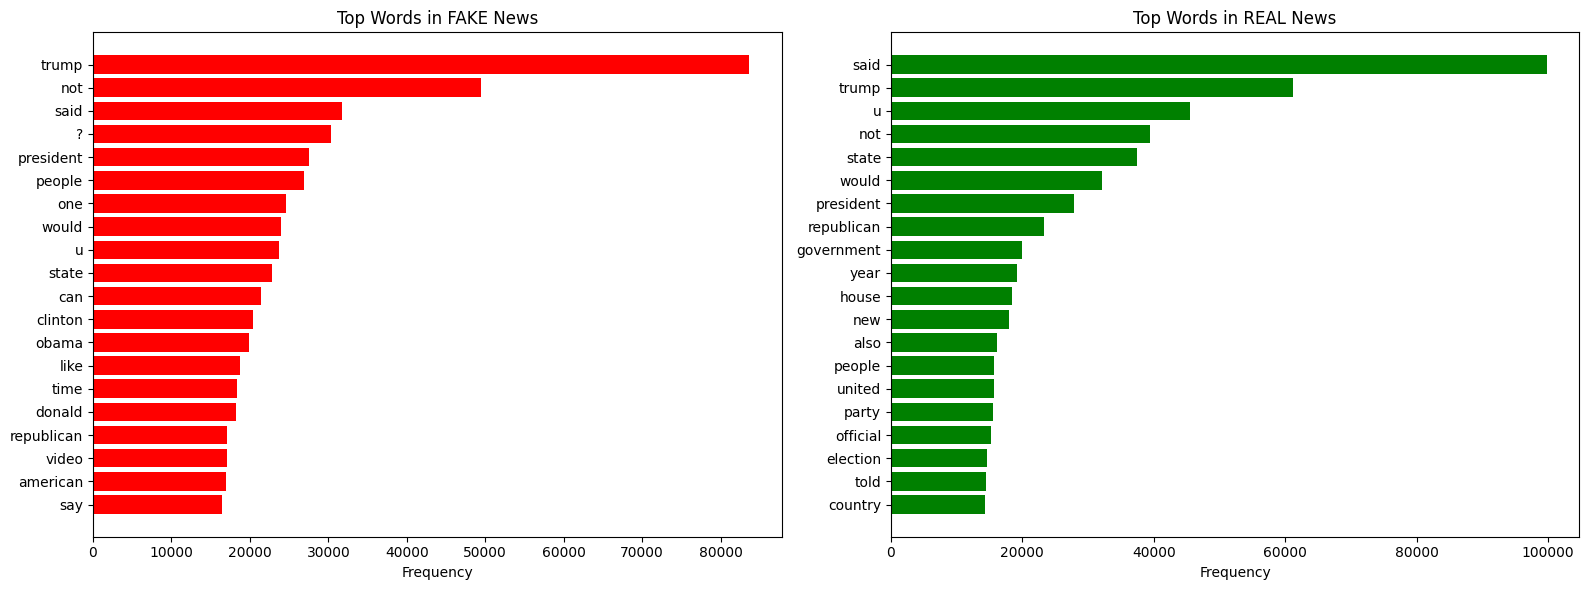

In [40]:
plot_word_frequencies(df_clean, top_n=20)

Training models...
Saving models...
Model: Naive Bayes
Train Accuracy: 0.9275
Test Accuracy: 0.9273
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.93      0.94      0.93      7108
        TRUE       0.93      0.92      0.92      6488

    accuracy                           0.93     13596
   macro avg       0.93      0.93      0.93     13596
weighted avg       0.93      0.93      0.93     13596

Confusion Matrix:


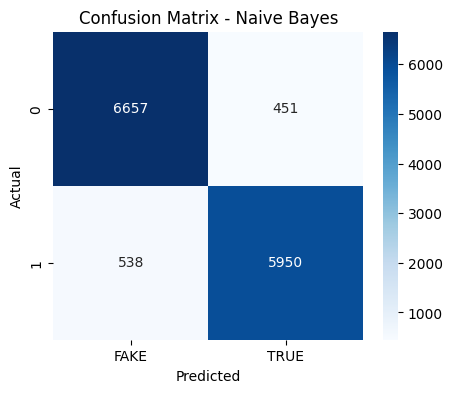

Model: Logistic Regression
Train Accuracy: 0.9825
Test Accuracy: 0.9765
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.97      0.98      7108
        TRUE       0.97      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix:


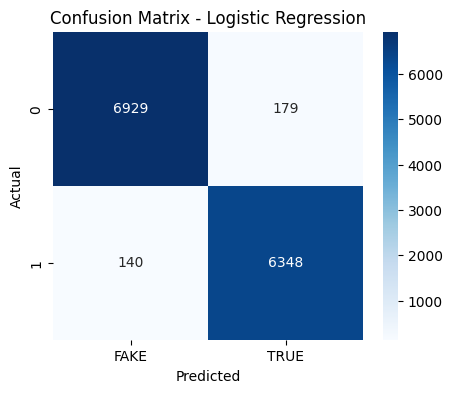

Model: Random Forest
Train Accuracy: 0.9981
Test Accuracy: 0.9798
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98      7108
        TRUE       0.98      0.98      0.98      6488

    accuracy                           0.98     13596
   macro avg       0.98      0.98      0.98     13596
weighted avg       0.98      0.98      0.98     13596

Confusion Matrix:


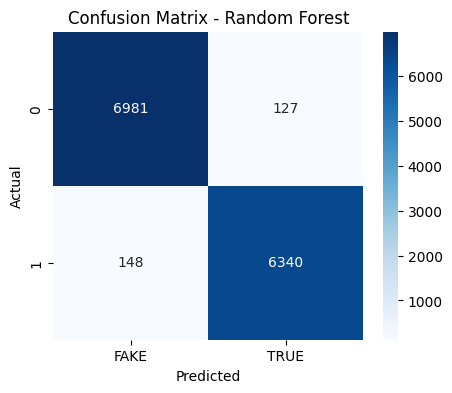

In [41]:
model_config, vectorizer = train_classic_models(df_clean)

In [ ]:
roberta_pretrained(df_clean.copy())

Using device: cuda
                                    text_transformer  label
0  <title>proof mainstream media manipulating ele...      0
1  <title>charity clinton foundation distributed ...      0
2  <title>hillary clinton administration may enti...      0
3  <title>trumps latest campaign promise may horr...      0
4  <title>website maintenance<content>website mai...      0
------------------------------------------------------------


Device set to use cuda:0


In [ ]:
# https://www.kaggle.com/code/jaskaransingh/fake-news-classification-bert-roberta

In [ ]:
# sentiment analysis on the dataset
